# Generated qLDLC decoding

This notebook loads one generated qLDLC code by name, prepares the decoding experiment, and runs a tiny smoke decode. The generated-code loading hides the JLD2 conversion and matrix setup details.

In [1]:
using Random

function find_repo_file(parts...)
    starts = unique(normpath.([@__DIR__, pwd()]))

    for start in starts
        current = start
        while true
            candidate = normpath(joinpath(current, parts...))
            isfile(candidate) && return candidate

            parent = dirname(current)
            parent == current && break
            current = parent
        end
    end

    error("Could not find repository file: " * joinpath(parts...))
end

include(find_repo_file("experiments", "decode_qldlc_codes.jl"));

Random.seed!(1);

function is_not_logical_error(logical_check, residual; atol = 1e-5)
    logical_coordinates = logical_check' * residual
    return all(abs(x - round(x)) < atol for x in logical_coordinates)
end;



Choose a generated qLDLC by filename stem. The helper also accepts a full path or a `.jld2` filename.

In [2]:
code_name = "reduced_ldlc_gkp_n_13_3"

qec_problem = load_qldlc_generated_code(code_name);

display(qec_problem.H)


26×26 Matrix{Float64}:
 -2.0   1.0   0.0   0.0   0.0  0.0  …  0.0   0.0   0.0   0.0   0.0   1.0
  0.0   0.0   0.0   0.0   1.0  0.0     0.0   0.0   0.0  -1.0   0.0  -1.0
  0.0  -1.0   0.0   0.0   0.0  0.0     0.0  -2.0   0.0   0.0   1.0   0.0
  0.0   0.0   0.0   0.0   0.0  0.0     1.0   0.0  -2.0   0.0   0.0   0.0
  1.0   0.0   0.0   0.0   0.0  2.0     1.0   0.0   0.0   0.0   0.0   0.0
  0.0   0.0   0.0   0.0   0.0  1.0  …  0.0  -1.0   0.0   0.0   0.0   2.0
  0.0   0.0   0.0   0.0   0.0  0.0     0.0  -1.0   1.0   0.0   0.0   0.0
  0.0   0.0   0.0   0.0   0.0  0.0     0.0   0.0   0.0   0.0  -2.0   0.0
  0.0   0.0   0.0   0.0   0.0  1.0     0.0   0.0   0.0  -2.0  -1.0   0.0
  1.0   0.0   0.0  -1.0   0.0  0.0     0.0   0.0   0.0   1.0   0.0   0.0
  ⋮                            ⋮    ⋱  ⋮                             ⋮
  0.0   0.0   0.0   1.0   1.0  0.0     0.0   1.0   0.0   0.0   0.0   0.0
  0.0   0.0   0.0   2.0   0.0  0.0     0.0   0.0   0.0   0.0   0.0   0.0
  0.0   1.0   0.0   0.0   0.0 

The loaded `QECProblem` contains the concrete `H` and `G` matrices used by the decoder.

In [3]:
H = qec_problem.H;
G = qec_problem.G;
logical_check = qec_problem.logical_check;



noise_std = 0.2 / sqrt(2 * pi)
max_iter = 10
decoder = "lsd"

error_vector = sample_error(noise_std, size(H, 2));
received = copy(error_vector);

tanner_graph = initialize_tanner_graph(H);
bp_estimate = run_belief_propagation!(
    tanner_graph,
    received,
    noise_std,
    max_iter,
    decoder;
);

decoded_integer_correction = hard_decision(bp_estimate, H);

correction = received - G * decoded_integer_correction;
residual = error_vector - correction;

println("H * bp_estimate = ", H * bp_estimate)

logical_success = is_not_logical_error(logical_check, residual)

H * bp_estimate = [0.016123846755509104, -0.001715459250734437, -0.006252617484339203, -0.00881269741164958, -0.0014378866900354378, 0.00010816476532614794, 0.014234532932438093, -0.002029975209649949, -0.010754189704669617, 0.001874088649506622, 0.015873023317351954, 0.0023292577007938573, -0.014905158413654078, -0.0071824807613098274, -0.00030628203561408086, -0.008537884274268753, 0.013846146520519433, -0.003513265334217046, 0.007601952367870244, 0.005913083043043874, -0.006511378541922394, -0.006191109464335233, 0.006861945333868612, 0.013733333690891057, 0.002339572888368768, 0.012979389683177888]


true

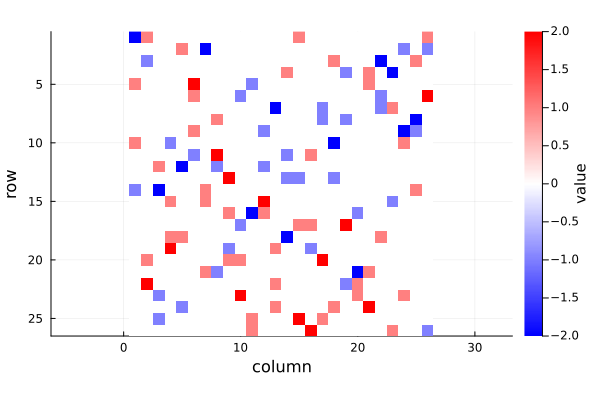

In [4]:
using Plots
my_gradient = cgrad([:blue, :white, :red], [-2, 0.0, 2.0])
p = heatmap(
        H;
        aspect_ratio=:equal,
        color=my_gradient,
        xlabel="column",
        ylabel="row",
        yflip=true,
        colorbar_title="value",
    )

